## Cell 1 — load the cleaned data from Day 2:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/stations_2025_clean.csv")
df.shape

(414, 19)

## Q1 — Which stations receive the highest annual passenger demand?
### Cell 2:

In [2]:
top20 = df.sort_values('Annualised', ascending=False).head(20)
top20[['Mode', 'Station', 'Annualised']]

,Mode,Station,Annualised
128,LU,King's Cross St. Pancras,7.357147e+07
245,LU,Waterloo LU,7.078675e+07
227,LU,Tottenham Court Road,6.081350e+07
240,LU,Victoria LU,6.015652e+07
138,LU,Liverpool Street LU,6.007762e+07
171,LU,Paddington TfL,5.796747e+07
139,LU,London Bridge LU,5.619407e+07
219,LU,Stratford,5.319312e+07
170,LU,Oxford Circus,5.233842e+07
24,LU,Bond Street,4.230423e+07


## Cell 3 — chart it:

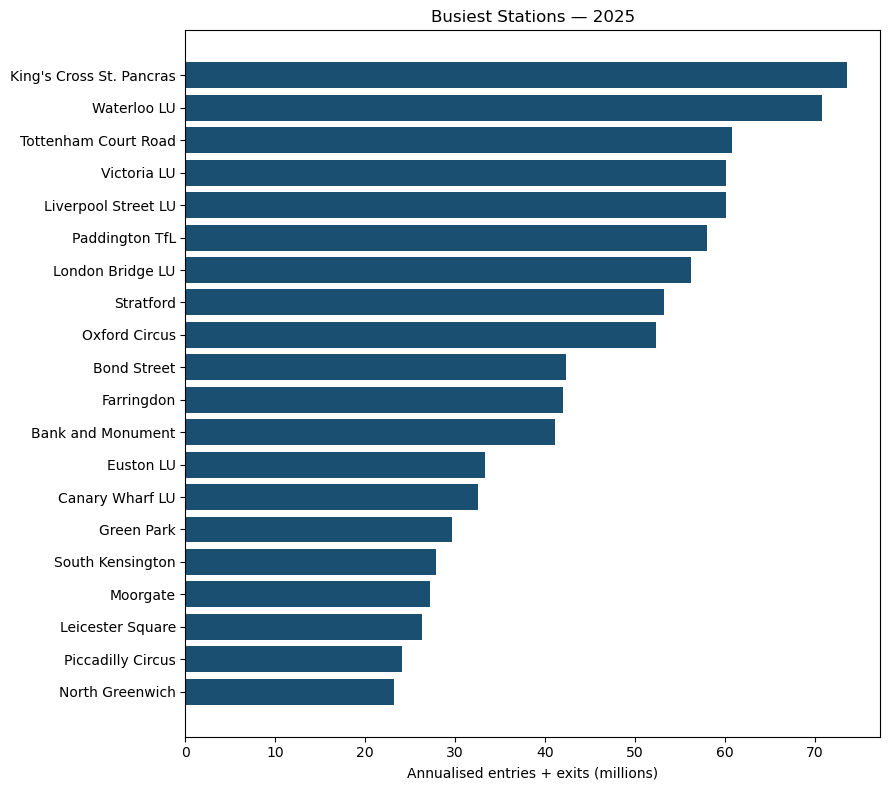

In [3]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_data = top20.sort_values('Annualised')
ax.barh(plot_data['Station'], plot_data['Annualised'] / 1e6, color='#1B4F72')
ax.set_xlabel('Annualised entries + exits (millions)')
ax.set_title("Busiest Stations — 2025")
plt.tight_layout()
plt.savefig('../powerbi/top20_busiest_2025.png', dpi=150)
plt.show()

In [7]:
day_cols = ['Monday', 'Midweek (Tue-Thu)', 'Friday', 'Saturday', 'Sunday',
            'Monday.1', 'Midweek (Tue-Thu).1', 'Friday.1', 'Saturday.1', 'Sunday.1']

bad = df[df[day_cols].apply(lambda col: col.apply(lambda x: isinstance(x, str))).any(axis=1)]
print(len(bad))
bad[['Mode', 'Station'] + day_cols]

414


,Mode,Station,Monday,Midweek (Tue-Thu),Friday,Saturday,Sunday,Monday.1,Midweek (Tue-Thu).1,Friday.1,Saturday.1,Sunday.1
0,LU,Acton Town,7102.571429,7878.66666666666,7755.2,5944.5,4493.75,7227.99999999999,8004.83333333333,7823.4,6212.75,4674.75
1,LU,Aldgate,10241.000000,12544.1999999999,9006.25,5965.5,4651.4,11675.8333333333,14425.8,11675.25,7933.25,5423.39999999999
2,LU,Aldgate East,17385.714286,20020.5,18113.7999999999,17370.3999999999,13301.9999999999,16194.7142857142,19654.625,18310.9999999999,17313.5999999999,11733.3333333333
3,LU,Alperton,3692.000000,3476.33333333333,3600.8,2553.33333333333,1932.4,3889.33333333333,3761.66666666666,3742.99999999999,2545.33333333333,1875.8
4,LU,Amersham,3223.666667,3835.625,2994.5,2459.66666666666,1334.83333333333,3066.99999999999,3741.625,2973.83333333333,2257.5,1250.33333333333
...,...,...,...,...,...,...,...,...,...,...,...,...
409,EZL,Taplow,794.677948,---,---,---,---,---,---,---,---,---
410,EZL,Twyford,2461.250931,---,---,---,---,---,---,---,---,---
411,EZL,West Drayton,6968.209741,3435.81533800309,2660.9526752297,2259.01434209848,1944.68362138543,1770.42765817838,2340.47443497547,1509.32743173591,1253.84704252125,1028.79666388657
412,EZL,West Ealing,4427.400056,7232.41599467536,7166.1650398946,5863.6364317555,3525.13812787509,6721.45648134541,6870.26907986736,6353.54024117276,5399.18142656415,3392.71596891496


In [9]:
for col in day_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

incomplete = df[df[day_cols].isna().any(axis=1)]
print(f"Excluded from weekday/weekend analysis (incomplete day data): {len(incomplete)}")
print(incomplete['Station'].tolist())

day_level_df = df.dropna(subset=day_cols).copy()
print(day_level_df.shape)

Excluded from weekday/weekend analysis (incomplete day data): 3
['Taplow', 'Twyford', 'Woolwich EL']
(411, 19)


### Feature engineering before Q2–Q5, we need weekday/weekend combined footfall.
### The day-of-week columns are entries and exits kept separate (Monday = entry, Monday.1 = exit, etc.), and Midweek (Tue-Thu) is already a single average value representing a typical Tue/Wed/Thu day not a sum of three days. So a weekday average has to weight it properly: Monday counts once, Midweek counts as 3 (Tue+Wed+Thu), Friday counts once, divided by 5 total days.

## Cell 4:

In [11]:
day_level_df['weekday_avg_daily'] = (
    (day_level_df['Monday'] + day_level_df['Monday.1']) +
    3 * (day_level_df['Midweek (Tue-Thu)'] + day_level_df['Midweek (Tue-Thu).1']) +
    (day_level_df['Friday'] + day_level_df['Friday.1'])
) / 5

day_level_df['weekend_avg_daily'] = (
    (day_level_df['Saturday'] + day_level_df['Saturday.1']) +
    (day_level_df['Sunday'] + day_level_df['Sunday.1'])
) / 2

day_level_df[['Station', 'weekday_avg_daily', 'weekend_avg_daily']].head()

,Station,weekday_avg_daily,weekend_avg_daily
0,Acton Town,15511.934286,10662.875000
1,Aldgate,24701.666667,11986.775000
2,Aldgate East,37806.120714,29859.666667
3,Alperton,7327.826667,4453.433333
4,Amersham,6998.150000,3651.166667
